In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('../Dataset/Customer_churn.csv')
df.head()
df.tail()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.isnull().sum()

gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
Churn                 0
Churn_Binary          0
tenure_group         11
avg_monthly_spend     0
dtype: int64

In [4]:
df = df.dropna(subset=['TotalCharges'])
df = df.drop('customerID', axis=1)
df.isnull().sum()

gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
Churn                 0
Churn_Binary          0
tenure_group         11
avg_monthly_spend     0
dtype: int64

In [5]:
df['InternetService'] = df['InternetService'].replace('No internet service', 'No')
df['PhoneService'] = df['PhoneService'].replace('No phone service', 'No')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,tenure_group,avg_monthly_spend
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,75.825000


In [6]:
df.duplicated().sum()

np.int64(0)

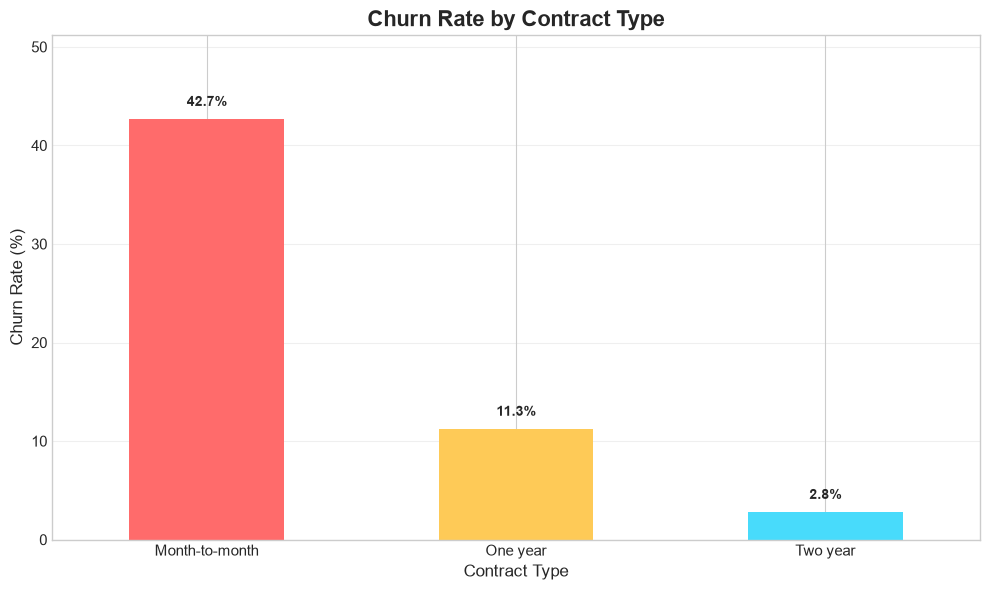

In [7]:
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

churn_by_contract = df.groupby('Contract')['Churn_Binary'].mean() * 100

plt.figure(figsize=(10, 6))
churn_by_contract.plot(kind='bar', color=['#ff6b6b', '#feca57', '#48dbfb'])
plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max(churn_by_contract) * 1.2)

for i, v in enumerate(churn_by_contract):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:

df_encoded = df.copy()


columns_to_encode = [
    'Contract', 'InternetService', 'PaymentMethod',
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]


columns_to_encode = [col for col in columns_to_encode if col in df_encoded.columns]
print(f"✅ Encoding {len(columns_to_encode)} columns")

df_encoded = pd.get_dummies(df_encoded, columns=columns_to_encode, drop_first=False)
print("✅ One-hot encoding complete")

print("ENCODING SUMMARY")
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")
print(f"Total columns: {len(df_encoded.columns)}")
print(f"Null values: {df_encoded.isnull().sum().sum()}")

print("\nData types:")
print(df_encoded.dtypes.value_counts())

print("\nFirst row sample:")
display(df_encoded.iloc[0, :10])

✅ Encoding 12 columns
✅ One-hot encoding complete
ENCODING SUMMARY
Original shape: (7043, 24)
Encoded shape: (7043, 47)
Total columns: 47
Null values: 11

Data types:
bool        35
str          5
int64        3
float64      3
category     1
Name: count, dtype: int64

First row sample:


customerID        7590-VHVEG
gender                Female
SeniorCitizen              0
Partner                  Yes
Dependents                No
tenure                     1
MonthlyCharges         29.85
TotalCharges           29.85
Churn                     No
Churn_Binary               0
Name: 0, dtype: object

In [9]:

# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                            bins=[0, 12, 24, 48, float('inf')],
                            labels=['0-12 months', '13-24 months', '25-48 months', '49+ months'])


print("TENURE GROUP DISTRIBUTION")
print(df['tenure_group'].value_counts().sort_index())
print(f"\nTotal customers: {len(df):,}")


# Basic statistics by group
print("\nGroup Statistics:")
stats = df.groupby('tenure_group')['tenure'].agg(['count', 'min', 'max', 'mean', 'median'])
print(stats)



TENURE GROUP DISTRIBUTION
tenure_group
0-12 months     2175
13-24 months    1024
25-48 months    1594
49+ months      2239
Name: count, dtype: int64

Total customers: 7,043

Sample of data:


,tenure,tenure_group
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months
5,8,0-12 months
6,22,13-24 months
7,10,0-12 months
8,28,25-48 months
9,62,49+ months



Group Statistics:
              count  min  max       mean  median
tenure_group                                    
0-12 months    2175    1   12   4.755402     4.0
13-24 months   1024   13   24  18.351562    18.0
25-48 months   1594   25   48  36.191343    36.0
49+ months     2239   49   72  63.048682    64.0


In [10]:
# Create avg_monthly_spend feature

df['avg_monthly_spend'] = np.where(df['tenure'] == 0, 
                                    df['MonthlyCharges'],  # or 0
                                    df['TotalCharges'] / df['tenure'])

print(df[['tenure', 'TotalCharges', 'MonthlyCharges', 'avg_monthly_spend']].head(10))
print(f"\nStats:\n{df['avg_monthly_spend'].describe()}")

   tenure  TotalCharges  MonthlyCharges  avg_monthly_spend
0       1         29.85           29.85          29.850000
1      34       1889.50           56.95          55.573529
2       2        108.15           53.85          54.075000
3      45       1840.75           42.30          40.905556
4       2        151.65           70.70          75.825000
5       8        820.50           99.65         102.562500
6      22       1949.40           89.10          88.609091
7      10        301.90           29.75          30.190000
8      28       3046.05          104.80         108.787500
9      62       3487.95           56.15          56.257258

Stats:
count    7043.000000
mean       64.762906
std        30.189796
min        13.775000
25%        35.935156
50%        70.337500
75%        90.174158
max       121.400000
Name: avg_monthly_spend, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split

df_clean = df.dropna(subset=['Churn'])

X = df_clean.drop(columns=['Churn', 'Churn_Binary'], errors='ignore')
y = df_clean['Churn']

y = y.map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

X_train: (5634, 23)
X_test: (1409, 23)

Train churn rate: 26.54%
Test churn rate: 26.54%


In [12]:
# Complete preprocessing and training
X_train_clean = X_train.drop('customerID', axis=1, errors='ignore')
X_test_clean = X_test.drop('customerID', axis=1, errors='ignore')

X_train_encoded = pd.get_dummies(X_train_clean)
X_test_encoded = pd.get_dummies(X_test_clean)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Training accuracy: {model.score(X_train_scaled, y_train):.4f}")
print(f"Test accuracy: {model.score(X_test_scaled, y_test):.4f}")
# Save model to disk
import joblib
joblib.dump(model, '../Model/churn_model.pkl')
print('✅ Model successfully saved to Model/churn_model.pkl!')


Training accuracy: 1.0000
Test accuracy: 1.0000


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

MODEL PERFORMANCE METRICS
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


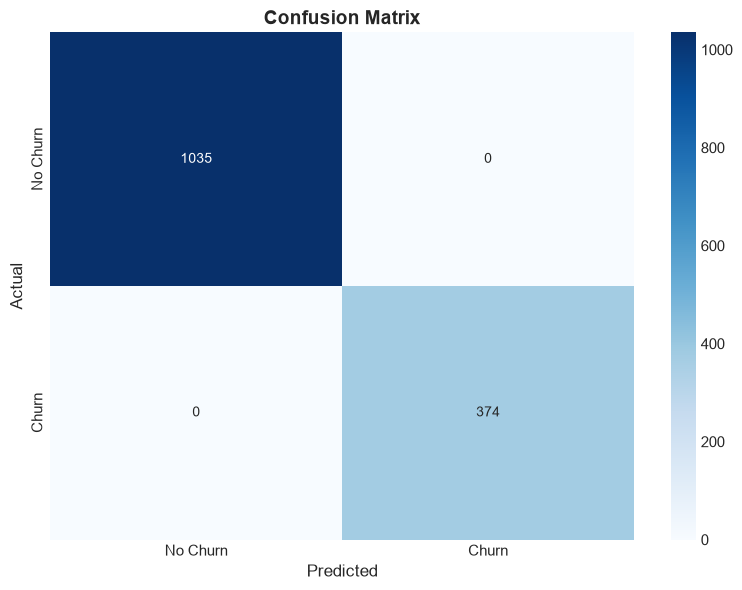

In [14]:

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
feature_names = X_train_encoded.columns
coefficients = model.coef_[0]

# Create and sort DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print("=" * 50)
print("STRONGEST CHURN DRIVERS (Top 10)")
print("=" * 50)
print(feature_importance.head(10))

print("\n" + "=" * 50)
print("BIGGEST CHURN REDUCERS (Bottom 10)")
print("=" * 50)
print(feature_importance.tail(10))

STRONGEST CHURN DRIVERS (Top 10)
                           Feature  Coefficient
4                     Churn_Binary     5.837648
47        tenure_group_0-12 months     0.111907
38         Contract_Month-to-month     0.106818
18     InternetService_Fiber optic     0.105255
45  PaymentMethod_Electronic check     0.070392
20               OnlineSecurity_No     0.058717
5                avg_monthly_spend     0.051354
29                  TechSupport_No     0.050884
2                   MonthlyCharges     0.047562
42            PaperlessBilling_Yes     0.045033

BIGGEST CHURN REDUCERS (Bottom 10)
                      Feature  Coefficient
50    tenure_group_49+ months    -0.035032
31            TechSupport_Yes    -0.038716
14           MultipleLines_No    -0.043597
41        PaperlessBilling_No    -0.045033
22         OnlineSecurity_Yes    -0.047553
49  tenure_group_25-48 months    -0.051265
17        InternetService_DSL    -0.093548
40          Contract_Two year    -0.097063
1               

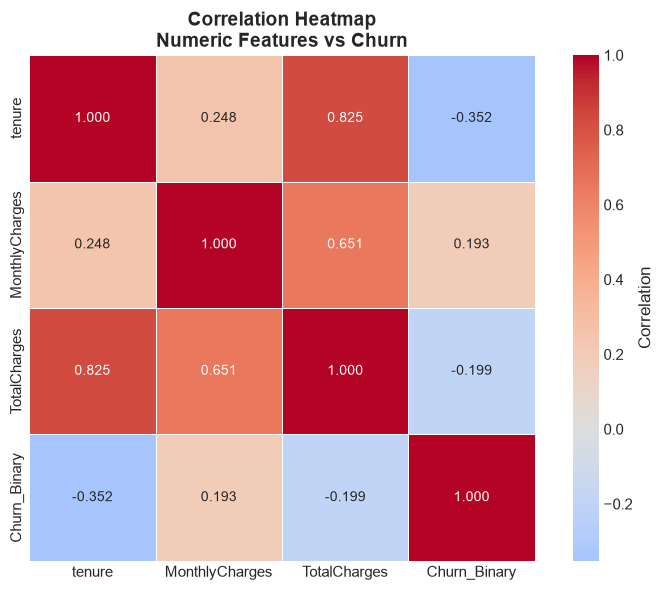


Correlations with Churn:
tenure: -0.352
MonthlyCharges: 0.193
TotalCharges: -0.199


In [16]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
correlation_data = df[numeric_features + ['Churn_Binary']]
correlation_matrix = correlation_data.corr()

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap\nNumeric Features vs Churn', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelations with Churn:")
for feature in numeric_features:
    corr = correlation_matrix.loc[feature, 'Churn_Binary']
    print(f"{feature}: {corr:.3f}")

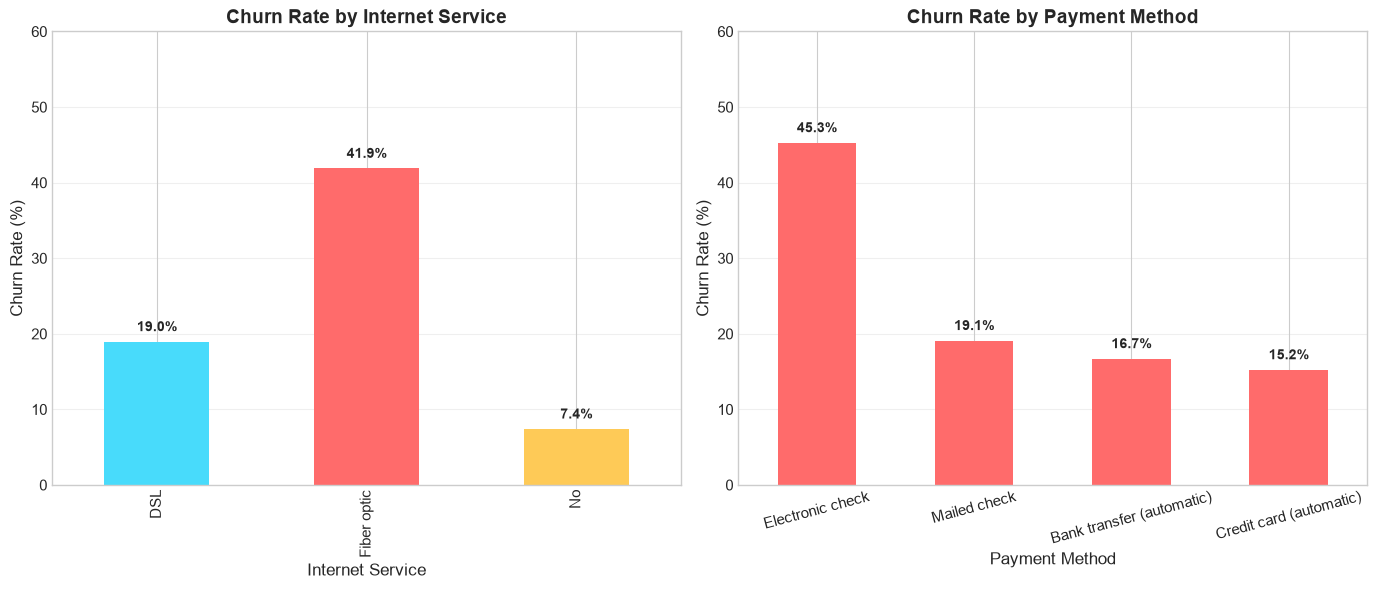


CHURN RATE BY INTERNET SERVICE & PAYMENT METHOD
PaymentMethod    Bank transfer (automatic)  Credit card (automatic)  \
InternetService                                                       
DSL                                   9.36                    12.12   
Fiber optic                          28.95                    25.29   
No                                    5.42                     2.72   

PaymentMethod    Electronic check  Mailed check  
InternetService                                  
DSL                         31.94         20.72  
Fiber optic                 53.23         42.64  
No                          12.30          9.58  


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100
internet_churn.plot(kind='bar', ax=ax1, color=['#48dbfb', '#ff6b6b', '#feca57'])
ax1.set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
ax1.set_xlabel('Internet Service')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_ylim(0, 60)
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(internet_churn):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Churn by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean() * 100
payment_churn.sort_values(ascending=False).plot(kind='bar', ax=ax2, color='#ff6b6b')
ax2.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_ylim(0, 60)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)

for i, v in enumerate(payment_churn.sort_values(ascending=False)):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CHURN RATE BY INTERNET SERVICE & PAYMENT METHOD")
print("=" * 60)

cross_tab = pd.crosstab(df['InternetService'], 
                        df['PaymentMethod'], 
                        values=df['Churn_Binary'], 
                        aggfunc='mean') * 100

print(cross_tab.round(2))

In [18]:
X = df.drop('Churn_Binary', axis=1)
y = df['Churn_Binary']

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features: (7043, 23)
Target: (7043,)

Target distribution:
Churn_Binary
0    5174
1    1869
Name: count, dtype: int64


In [19]:
y = y.map({'Yes': 1, 'No': 0})

print(f"Target distribution:\n{y.value_counts()}")
print(f"\nTarget sample:\n{y.head()}")

Target distribution:
Series([], Name: count, dtype: int64)

Target sample:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Churn_Binary, dtype: float64


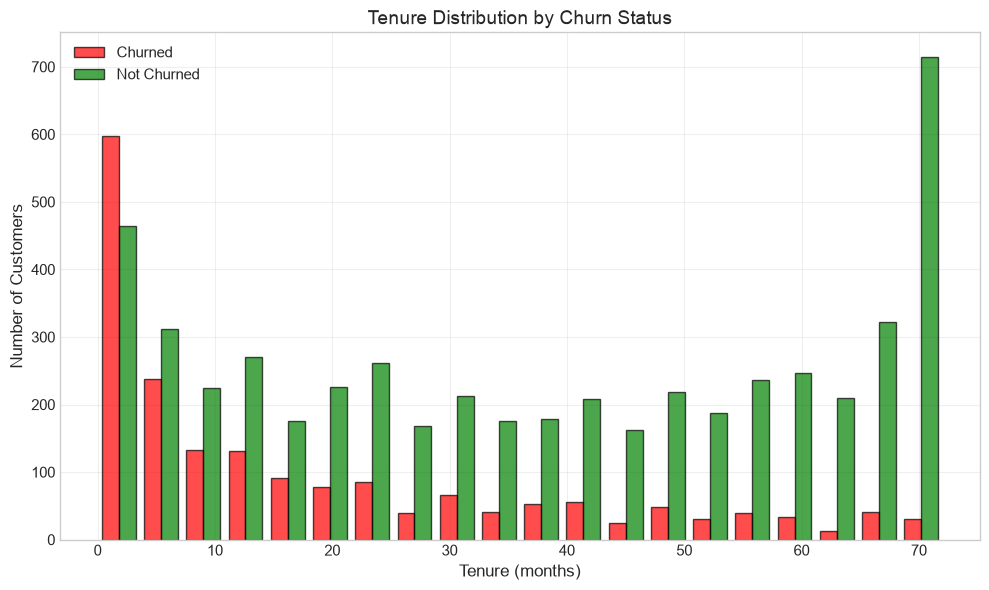


Churned customers - Mean tenure: 18.0 months
Not churned customers - Mean tenure: 37.6 months
Difference: 19.6 months


In [20]:

df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 6))

churned = df[df['Churn_Binary'] == 1]['tenure']
not_churned = df[df['Churn_Binary'] == 0]['tenure']

plt.hist([churned, not_churned], bins=20, 
         label=['Churned', 'Not Churned'],
         color=['red', 'green'], alpha=0.7, edgecolor='black')

plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Tenure Distribution by Churn Status')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nChurned customers - Mean tenure: {churned.mean():.1f} months")
print(f"Not churned customers - Mean tenure: {not_churned.mean():.1f} months")
print(f"Difference: {not_churned.mean() - churned.mean():.1f} months")